Original Image Size: (1280, 720)
Original Bit Depth: 8-bit
Intensity Range: 3 to 253


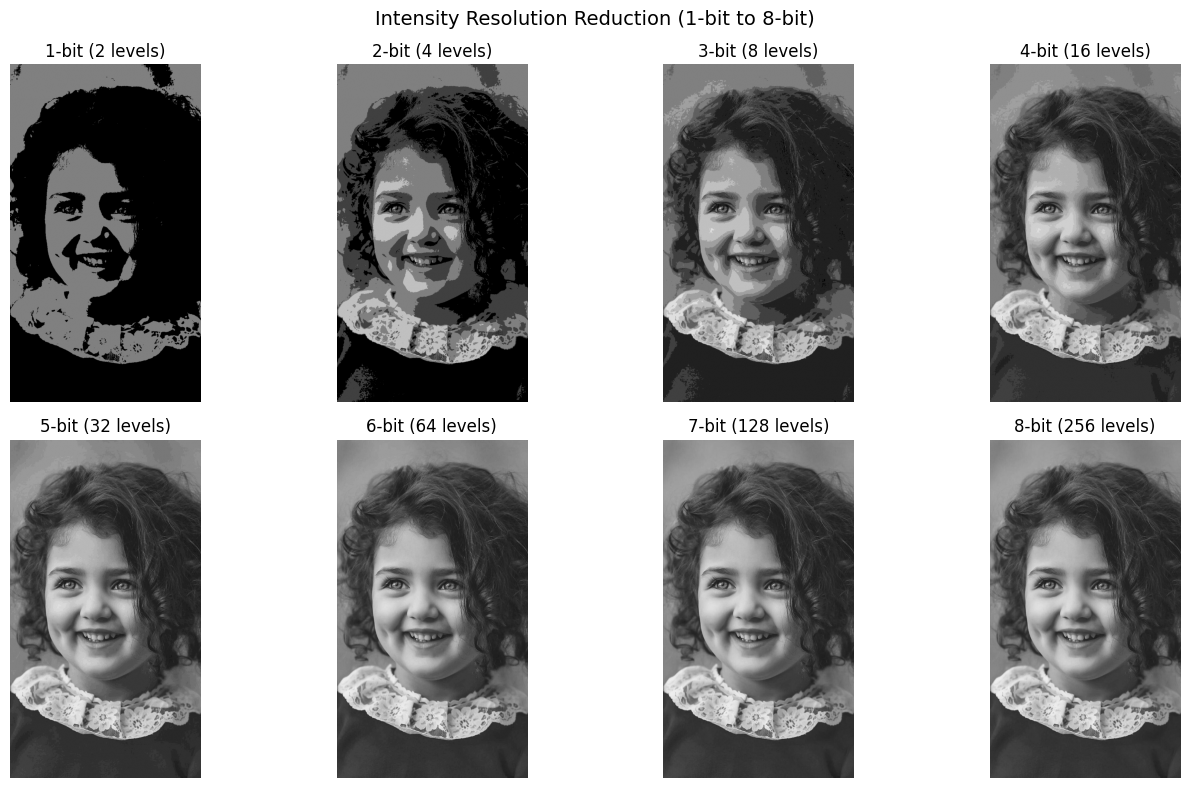

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1️⃣ Read the image in grayscale ---
img = cv2.imread('Images\pk.jpg', cv2.IMREAD_GRAYSCALE)

# --- 2️⃣ Display original info ---
print(f"Original Image Size: {img.shape}")
print(f"Original Bit Depth: 8-bit")
print(f"Intensity Range: {img.min()} to {img.max()}")

# --- 3️⃣ Create subplots for 1-bit to 8-bit images ---
plt.figure(figsize=(14, 8))

for bit in range(1, 9):
    # Calculate number of levels for this bit depth
    L = 2 ** bit
    
    # Reduce intensity resolution
    img_reduced = np.floor(img / (256 / L)) * (256 / L)
    img_reduced = img_reduced.astype(np.uint8)
    
    # Display the result
    plt.subplot(2, 4, bit)
    plt.imshow(img_reduced, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{bit}-bit ({L} levels)')
    plt.axis('off')

plt.suptitle('Intensity Resolution Reduction (1-bit to 8-bit)', fontsize=14)
plt.tight_layout()
plt.show()


Original image dtype: uint8, range: 3 - 253


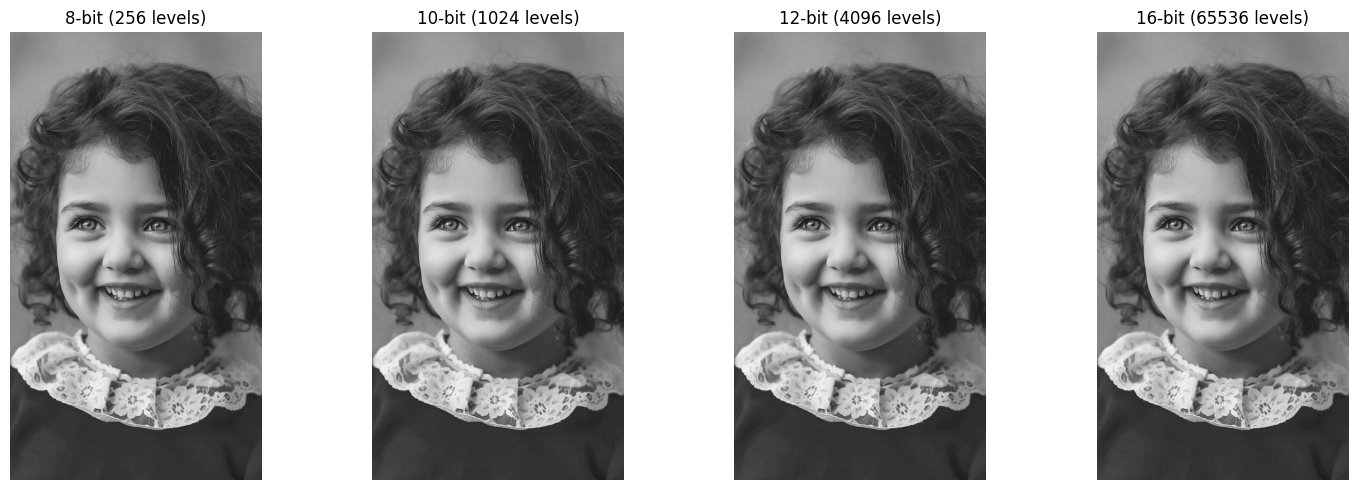

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1️⃣ Read image (grayscale) ---
img_8bit = cv2.imread('Images\pk.jpg', cv2.IMREAD_GRAYSCALE)
if img_8bit is None:
    raise FileNotFoundError("Image 'pk.jpg' not found!")

print(f"Original image dtype: {img_8bit.dtype}, range: {img_8bit.min()} - {img_8bit.max()}")

# --- 2️⃣ Convert to higher intensity resolutions ---
img_10bit = np.uint16(img_8bit) * 4         # Scale 0–255 → 0–1020
img_12bit = np.uint16(img_8bit) * 16        # Scale 0–255 → 0–4080
img_16bit = np.uint16(img_8bit) * 256       # Scale 0–255 → 0–65535

# --- 3️⃣ Normalize images for display (matplotlib needs 0–1 range) ---
img_8bit_disp = img_8bit / 255.0
img_10bit_disp = img_10bit / 1023.0
img_12bit_disp = img_12bit / 4095.0
img_16bit_disp = img_16bit / 65535.0

# --- 4️⃣ Display all images side by side ---
titles = ['8-bit (256 levels)', '10-bit (1024 levels)', '12-bit (4096 levels)', '16-bit (65536 levels)']
images = [img_8bit_disp, img_10bit_disp, img_12bit_disp, img_16bit_disp]

plt.figure(figsize=(15, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
